In [6]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
from matplotlib.patches import Rectangle
import re
import utils
import matplotlib.patches as mpatches

import pygmt
import glob
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib import colors

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
cell_dict = {
    0.01: (20, 4096),
    0.008: (20, 4096),
    0.0063: (20, 4096),
    0.005: (10, 8192),
    0.0039: (10, 8192),
    0.003: (5, 16384),
    0.002: (5, 16384),
    0.0014: (2.5, 32768),
    0.001: (2.5, 32768) 
} # DX and N2 info for each model from Motorcycle shell scripts 

cols = ['Index', 'Displacement', 'Col3', 'Col4', 'Col5', 'col', 'cplb','Slip Rate', 'Col7', 'Col8', 'Col9', 'Col10','Col11'] 
# time step conversion
plt.rcParams.update({'font.size': 10})
vmin = -12 # color limits
vmax = 1
cmap = plt.get_cmap('rocket')
cropped_cmap = colors.LinearSegmentedColormap.from_list('flare_cropped', cmap(np.linspace(0, 0.9, 256)))
m = 256  # Define the number of colors
cmap = mcolors.ListedColormap(utils.cycles_colormap(m))

time_step_rate = 20
grid_step_rate_horizontal = 4 

In [8]:
data = [
    {"lat": 35.062212, "lon": -116.043059, "symbol": "d", "color": "coral", "reference": "\nECSZ - Scholz, 2010;\nRockwell et al., 2000"},
    {"lat": 42.427170, "lon":13.220527, "symbol": "d", "color": "forestgreen", "reference": "Fucino fault system - Benedetti et al., 2012"},
    {"lat": 39.3077, "lon":-123.7995, "symbol": "d", "color": "steelblue", "reference": "Cascadia & SAF - Goldfinger et al., 2025"},
    {"lat": 35.442710, "lon":-117.845763, "symbol": "d", "color": "teal", "reference": "San Andreas & Garlock - Dolan et al., 2016"},
    {"lat": 32.750946,"lon":135.039338, "symbol": "d", "color": "red", "reference": "Nankai - Philibosian and Melzner, 2020"},
    {"lat": 45.249516, "lon":100.753478, "symbol": "d", "color": "goldenrod", "reference": "Mongolia - Chery et al., 2001"},
    {"lat": 38.517941, "lon":-116.243352, "symbol": "d", "color": "skyblue", "reference": "Basin and Range - Wallace, 1987; Bell et al., 2004"},
    {"lat": 63.45, "lon":-20, "symbol": "d", "color": "saddlebrown", "reference": "Iceland - Roth, 2004"},
    {"lat": 33.096505, "lon": 40.412162, "symbol": "^", "color": "black", "reference": "North & East Anatolian Faults - Ambraseys, 1971"},
    {"lat": 34.155744, "lon": -117.211283, "symbol": "^", "color": "plum", "reference": "San Andreas & San Jacinto - Bennett et al., 2004"},
    {"lat": 34.002378, "lon": -118.285667, "symbol": "^", "color": "purple", "reference": "ECSZ & LA Basin - Dolan et al., 2007"},
    {"lat": -42.359757, "lon": 172.619321, "symbol": "^", "color": "darkorange", "reference": "Marlborough fault system - Dolan et al., 2024"},
    {"lat": 38.0211 , "lon": 22.9881, "symbol": "^", "color": "brown", "reference": "Skinos & Pisia faults - Mitchell et al., 2025"},
    {"lat": 25, "lon": 103, "symbol": "^", "color": "peru", "reference": "Xiaojiang fault zone - Bai et al., 2025"},
    {"lat": -38.82, "lon":176.08, "symbol": "^", "color": "thistle", "reference": "Taupo Rift - Nicol et al., 2006"},
    {"lat": 34.8958, "lon":-117.0228, "symbol": "^", "color": "olive", "reference": "Garlock & ECSZ - Peltzer et al, 2001"}]


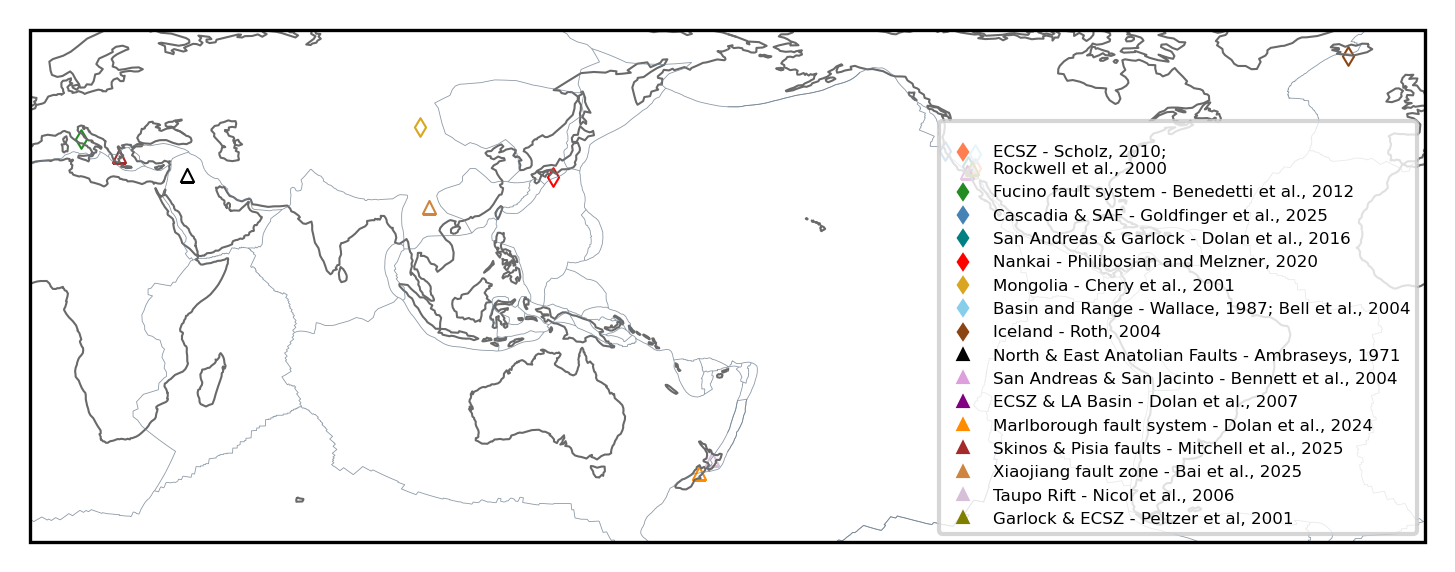

In [9]:
faults = gpd.read_file('shapefile/Tectonic_Plates_and_Boundaries.shp')
detailed_faults = gpd.read_file('shapefile/gem_active_faults_harmonized.shp')

faults = faults.to_crs(epsg=4326)
detailed_faults = detailed_faults.to_crs(epsg=4326)

fig, ax = plt.subplots(dpi=300,figsize=(6,4), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ax.set_extent([-80, 10, -60, 70], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='dimgray')
faults.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    color='slategray',
    alpha=0.8,
    linewidth=0.2
)

legend_handles = {}
for point in data:
    sc = ax.scatter(
        point["lon"], point["lat"],
        color=["none"],
        marker=point["symbol"],
        edgecolor=point["color"],
        s=10,
        linewidth=0.5,
        transform=ccrs.PlateCarree(),
        label=point["reference"]
    )
    
    legend_handles[point["reference"]] = mlines.Line2D(
        [], [], color=point["color"], marker=point["symbol"], linestyle='None', markersize=2, label=point["reference"]
    )

ax.legend(handles=legend_handles.values(), loc="lower right", fontsize=4)
#plt.savefig('Figures/mapref.png',bbox_inches='tight')

### Paper intro figure

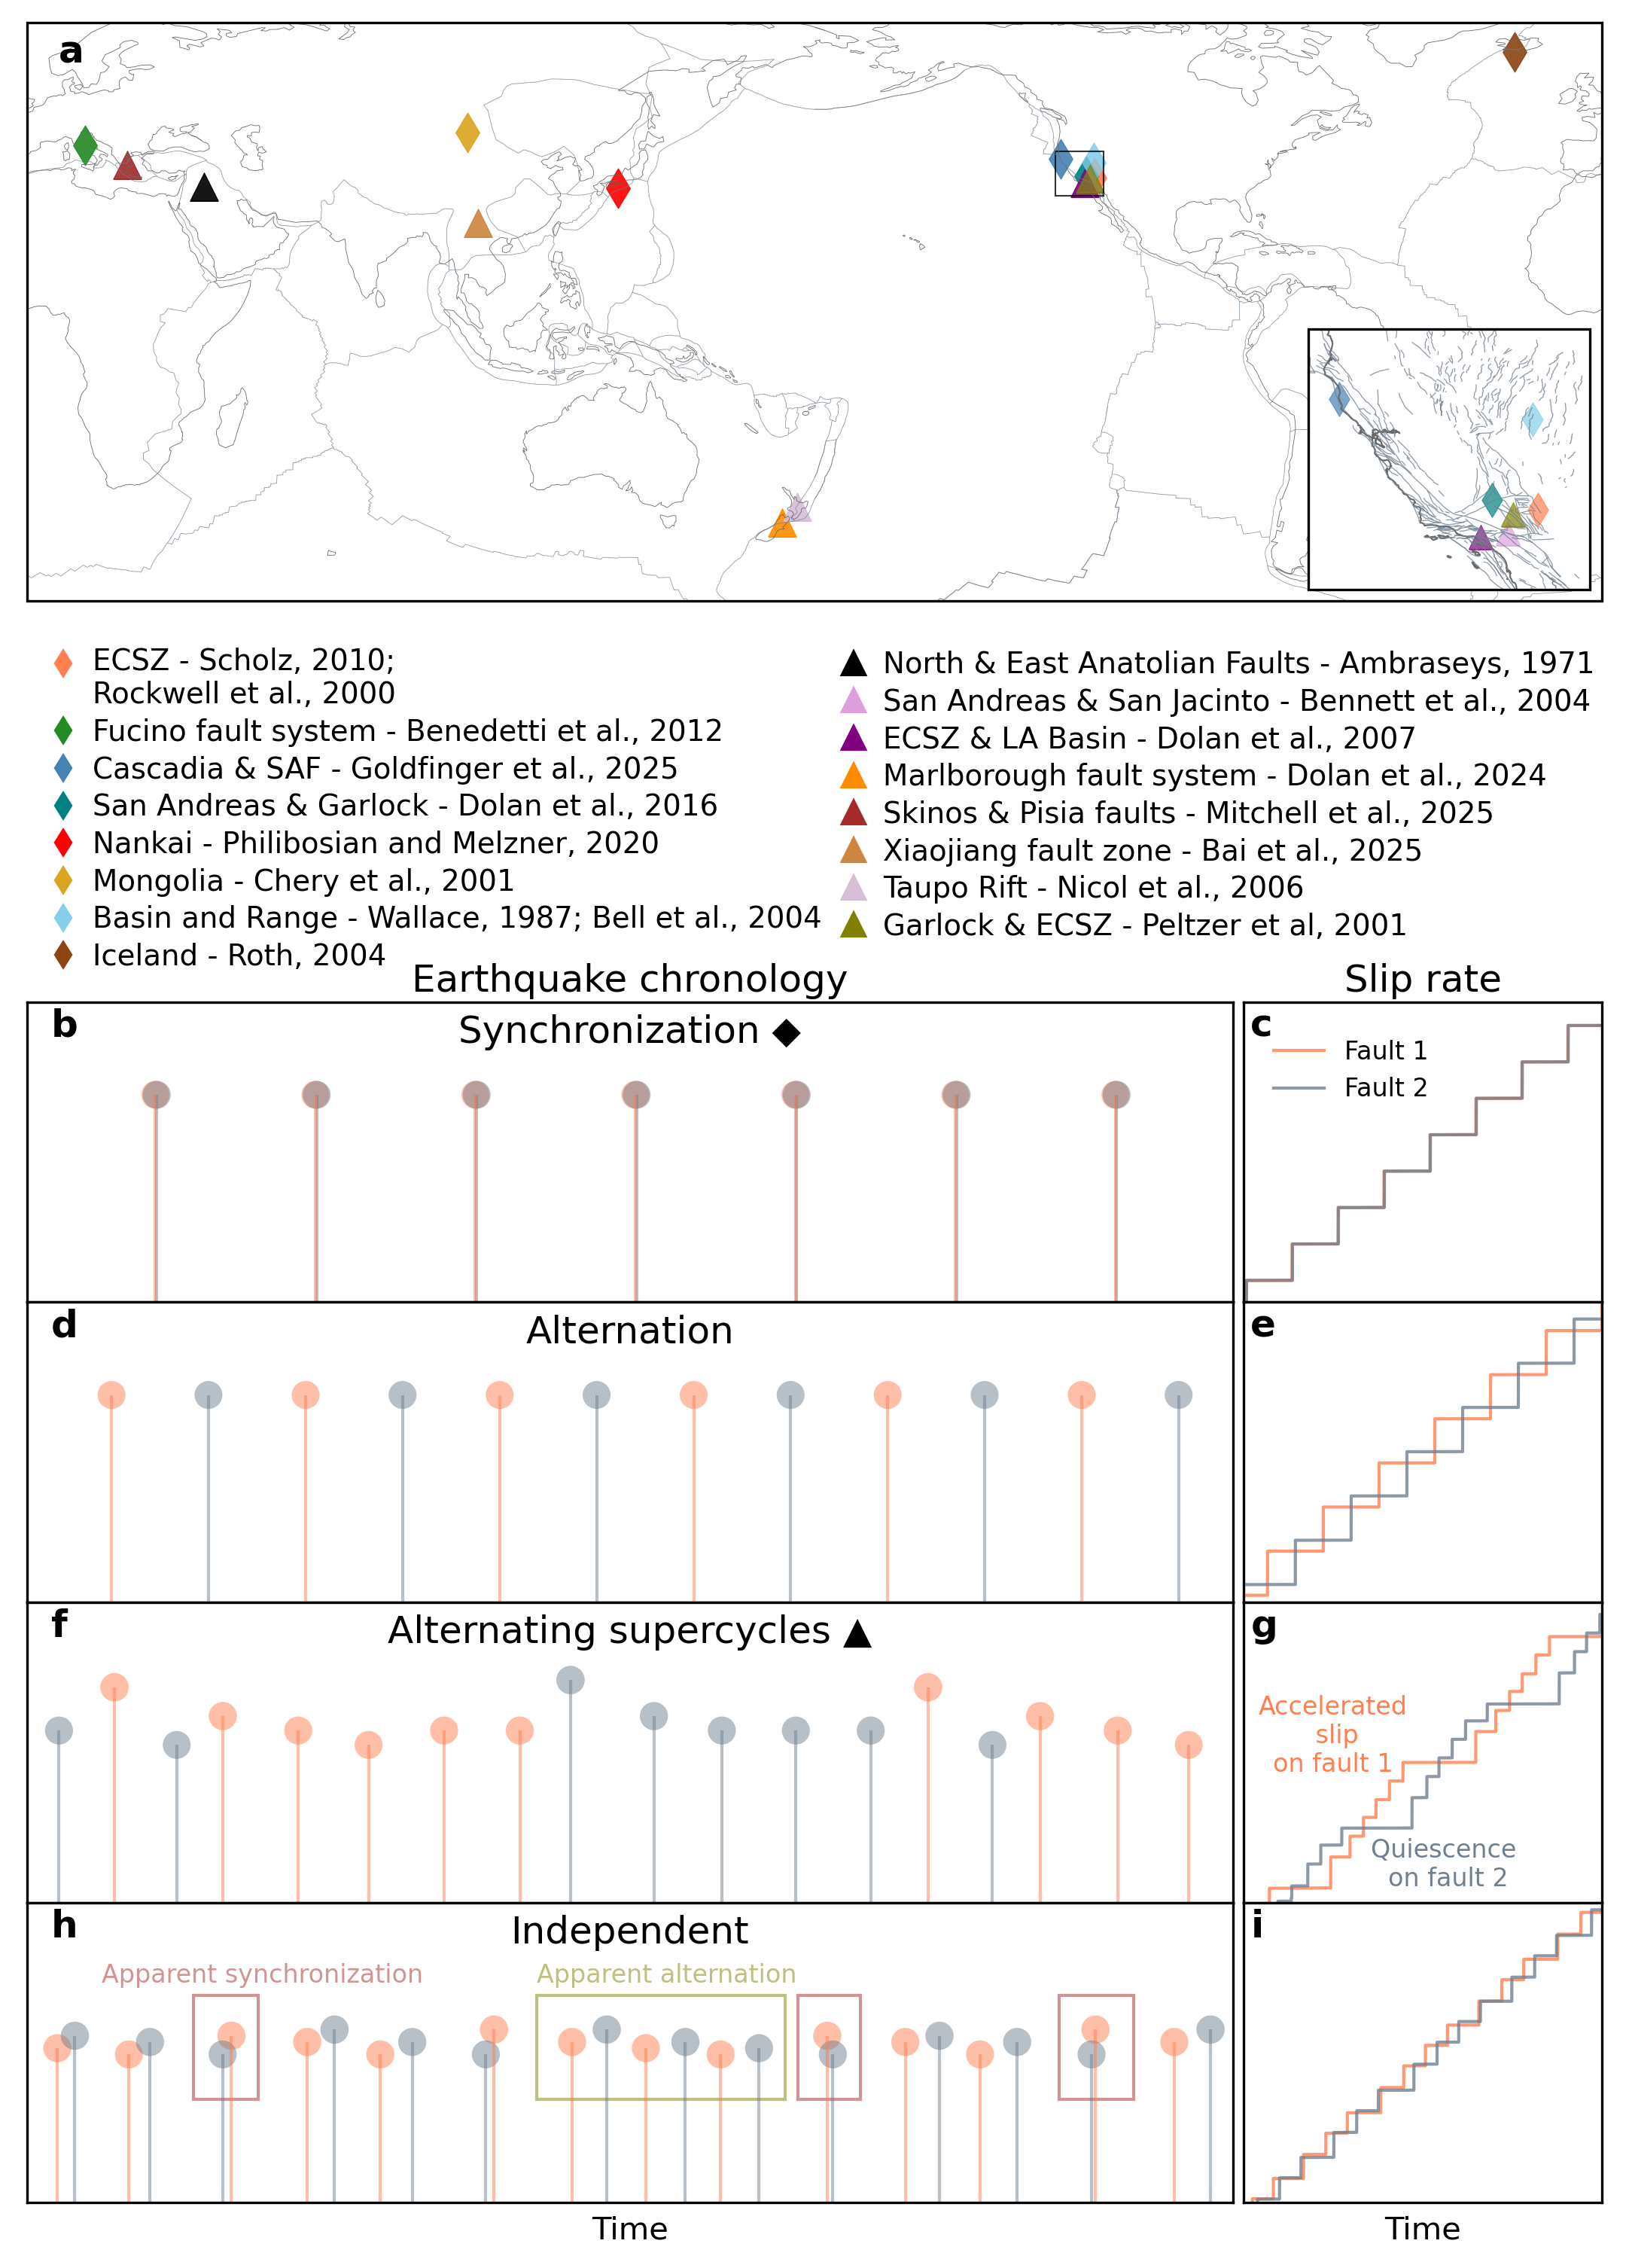

In [ ]:
fig = plt.figure(dpi=300,figsize=(9,10))
gs = gridspec.GridSpec(7, 3, figure=fig, width_ratios=[1, 1, 0.6], height_ratios=[1, 1, 1.3, 1, 1, 1, 1])
ax_legend = fig.add_subplot(gs[2, 0:3])
ax_legend.axis('off') 

# map
ax_main = fig.add_subplot(gs[0:2, 0:3], projection=ccrs.PlateCarree(central_longitude=180))
ax_main.set_extent([-80, 10, -60, 70], crs=ccrs.PlateCarree())
ax_main.add_feature(cfeature.COASTLINE, linewidth=0.2, edgecolor='dimgray')
faults.plot(
    ax=ax_main,
    transform=ccrs.PlateCarree(),
    color='slategray',
    alpha=0.8,
    linewidth=0.2
)

for point in data:
    sc = ax_main.scatter(
        point["lon"], point["lat"],
        color=point["color"],
        marker=point["symbol"],
        edgecolor=point["color"],
        s=80,
        alpha=0.7,
        linewidth=0.25,
        transform=ccrs.PlateCarree(),
        label=point["reference"]
    )
    
legend_handles = {}

for point in data:
    ax_main.scatter(
        point["lon"], point["lat"],
        color=point["color"],
        marker=point["symbol"],
        edgecolor=point["color"],
        s=80,
        alpha=0.7,
        linewidth=0.25,
        transform=ccrs.PlateCarree(),
        label=point["reference"]
    )

    if point["symbol"] == 'd':      # diamond
        msize = 5.5
    elif point["symbol"] == '^':    # triangle
        msize = 7
    else:
        msize = 7  # 

    legend_handles[point["reference"]] = mlines.Line2D(
        [], [],
        color=point["color"],
        marker=point["symbol"],
        linestyle='None',
        markersize=msize,
        label=point["reference"]
    )

handles = list(legend_handles.values())

# If odd number of items, insert an invisible dummy to push last item to right column
if len(handles) % 2 == 1:
    dummy = mlines.Line2D([], [], linestyle='None', marker=None, label='')
    handles.insert(len(handles)//2, dummy)

# --- Draw legend on ax_legend ---
ax_legend.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.06),
    ncol=2,
    fontsize=9.3,
    frameon=False,
    columnspacing=0.1,
    handletextpad=0.001,
    labelspacing=0.3
)

### CA inset 
ax_california = ax_main.inset_axes([0.613, 0.02, 0.58, 0.45], projection=ccrs.PlateCarree())
ax_california.set_extent([-125, -114, 32, 42], crs=ccrs.PlateCarree())
ax_california.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='dimgray')
detailed_faults.plot(
    ax=ax_california,
    transform=ccrs.PlateCarree(),
    color='slategray',
    alpha=0.8,
    linewidth=0.3
)

for point in data:
    sc = ax_california.scatter(
        point["lon"], point["lat"],
        color=point["color"],
        marker=point["symbol"],
        edgecolor=point["color"],
        s=60,
        alpha=0.7,
        linewidth=0.25,
        transform=ccrs.PlateCarree(),
        label=point["reference"]
    )
    
    california_box = mpatches.Rectangle(
    xy=(-125, 31),  
    width=11,       
    height=10,      
    linewidth=0.5,
    edgecolor='black',
    facecolor='none',
    alpha=0.8,
    transform=ccrs.PlateCarree()
)
ax_main.add_patch(california_box)

# catalogs and slip rates
### SYNCHRONIZATION
ax_left_1 = fig.add_subplot(gs[3, 0:2])
ax_right_1 = fig.add_subplot(gs[3, 2])

file_name = 'model_outputs/two_faults/inplane/Dc_008/output_Dc008_5km/'
dc = 0.008
DX, N2 = cell_dict[dc]
file_pattern = file_name + 'patch-01-*.dat'
matching_files = glob.glob(file_pattern)
fault_data = pd.read_csv(matching_files[0], sep='\s+', header=None, names=cols)

feature = 'log10v' # tau, slip, log10v
fault1_path = file_name + "fault-01-" + feature + ".grd"
grid_fault1 = pygmt.load_dataarray(fault1_path, engine='netcdf4')
fault2_path = file_name+ "fault-02-" + feature + ".grd"
grid_fault2 = pygmt.load_dataarray(fault2_path, engine='netcdf4')
delta_grid = time_step_rate   
time_grid = fault_data['Index'].iloc[::int(delta_grid)].values
grid_fault1 = grid_fault1.coarsen(x=6, boundary='trim').mean()
grid_fault2 = grid_fault2.coarsen(x=6, boundary='trim').mean()
grid1_masked = np.ma.masked_where(grid_fault1 < -3.5, grid_fault1) # subset areas where velocity>seismic slip to isolate events
grid2_masked = np.ma.masked_where(grid_fault2 < -3.5, grid_fault2)
grid1_masked = grid1_masked.filled(np.nan) # for viz in seaborn fill unmasked areas with nan
grid2_masked = grid2_masked.filled(np.nan)
timestep_event_fault1, rupture_length_pixels_fault1, group_id_fault1, total_pixels_fault1_xdir,pixel_size = utils.find_events(grid1_masked,DX,N2,"No")
timestep_event_fault2, rupture_length_pixels_fault2, group_id_fault2, total_pixels_fault2_xdir,pixel_size  = utils.find_events(grid2_masked,DX,N2,"No")
time_f1 = time_grid[timestep_event_fault1]
time_f2 = time_grid[timestep_event_fault2]
rupture_length_fault1 = np.array(rupture_length_pixels_fault1) 
rupture_length_fault2 = np.array(rupture_length_pixels_fault2) 
scale_factor = 30
ax_left_1.scatter(time_f1/365/24/60/60, (rupture_length_fault1 * pixel_size) / 1000,
                c='coral', s=scale_factor * np.log(rupture_length_fault1 + 1), alpha=0.5, edgecolor='none',label='Fault 1')
ax_left_1.scatter(time_f2/365/24/60/60, (rupture_length_fault2 * pixel_size) / 1000,
                c='slategray', s=scale_factor * np.log(rupture_length_fault2 + 1), alpha=0.5, edgecolor='none',label='Fault 2')
ax_left_1.vlines(
    x=time_f2/365/24/60/60,
    ymin=0,
    ymax=(rupture_length_fault2 * pixel_size) / 1000,
    color='slategray',
    alpha=0.5,
    linewidth=1
)
ax_left_1.vlines(
    x=time_f1/365/24/60/60,
    ymin=0,
    ymax=(rupture_length_fault1 * pixel_size) / 1000,
    color='coral',
    alpha=0.5,
    linewidth=1
)
ax_left_1.set_xlim(310,600)
ax_left_1.set_ylim(3.5, 7.5)
file_patterns = [file_name + 'patch-01-*.dat', file_name + 'patch-02-*.dat']    
for pattern in file_patterns:
    file_paths = glob.glob(pattern)
    file_numbers = []
    for file_path in file_paths:
        match = re.search(r'-(\d+)\.dat$', file_path)
        if match:
            file_numbers.append((int(match.group(1)), file_path))

    if file_numbers: # to plot only mid point of fault
        file_numbers.sort()
        middle_index = len(file_numbers) // 2
        middle_file_path = file_numbers[middle_index][1]
        if 'patch-01' in middle_file_path:
            color = 'coral'
            label = 'Fault 1'
        elif 'patch-02' in middle_file_path:
            color = 'slategray'
            label = 'Fault 2'
        fault_data = pd.read_csv(middle_file_path, header=None, names=cols, sep='\s+')
        fault_data['Time (Years)'] = fault_data['Index'].apply(utils.seconds_to_years)
        ax_right_1.plot(fault_data['Time (Years)'], fault_data['Displacement'], label=label, linewidth=1, color=color, alpha=0.8)
        ax_right_1.set_xlim(300, 600)
        ax_right_1.set_ylim(10, 20)

ax_left_1.set_yticks([])
ax_right_1.set_yticks([])
ax_left_1.set_xticks([])
ax_right_1.set_xticks([])
ax_right_1.legend(loc='upper center', fontsize=8, frameon=False, bbox_to_anchor=(0.3, 0.95))

# Add text labels above panels b and c
ax_left_1.text(0.5, 1.01, 'Earthquake chronology', ha='center', va='bottom', fontsize=12, transform=ax_left_1.transAxes, clip_on=False)
ax_right_1.text(0.5, 1.01, 'Slip rate', ha='center', va='bottom', fontsize=12, transform=ax_right_1.transAxes, clip_on=False)
# ax_left_1.scatter(0.05, 0.1, marker='d', s=80, color='gainsboro', transform=ax_left_1.transAxes, zorder=10)


### MODE SWITCHING
ax_left_2 = fig.add_subplot(gs[4, 0:2])
ax_right_2 = fig.add_subplot(gs[4, 2])
file_name = 'model_outputs/two_faults/antiplane/Dc_01/output_Dc01_5km/'
dc = 0.01
DX, N2 = cell_dict[dc]
file_pattern = file_name + 'patch-01-*.dat'
matching_files = glob.glob(file_pattern)
fault_data = pd.read_csv(matching_files[0], sep='\s+', header=None, names=cols)

feature = 'log10v' # tau, slip, log10v
fault1_path = file_name + "fault-01-" + feature + ".grd"
grid_fault1 = pygmt.load_dataarray(fault1_path, engine='netcdf4')
fault2_path = file_name+ "fault-02-" + feature + ".grd"
grid_fault2 = pygmt.load_dataarray(fault2_path, engine='netcdf4')
delta_grid = time_step_rate   
time_grid = fault_data['Index'].iloc[::int(delta_grid)].values
grid_fault1 = grid_fault1.coarsen(x=6, boundary='trim').mean()
grid_fault2 = grid_fault2.coarsen(x=6, boundary='trim').mean()
grid1_masked = np.ma.masked_where(grid_fault1 < -3.5, grid_fault1) # subset areas where velocity>seismic slip to isolate events
grid2_masked = np.ma.masked_where(grid_fault2 < -3.5, grid_fault2)
grid1_masked = grid1_masked.filled(np.nan) # for viz in seaborn fill unmasked areas with nan
grid2_masked = grid2_masked.filled(np.nan)
timestep_event_fault1, rupture_length_pixels_fault1, group_id_fault1, total_pixels_fault1_xdir,pixel_size = utils.find_events(grid1_masked,DX,N2,"No")
timestep_event_fault2, rupture_length_pixels_fault2, group_id_fault2, total_pixels_fault2_xdir,pixel_size  = utils.find_events(grid2_masked,DX,N2,"No")
time_f1 = time_grid[timestep_event_fault1]
time_f2 = time_grid[timestep_event_fault2]
rupture_length_fault1 = np.array(rupture_length_pixels_fault1) 
rupture_length_fault2 = np.array(rupture_length_pixels_fault2) 
scale_factor = 30
ax_left_2.scatter(time_f1/365/24/60/60, (rupture_length_fault1 * pixel_size) / 1000,
                c='coral', s=scale_factor * np.log(rupture_length_fault1 + 1), alpha=0.5, edgecolor='none',label='Fault 1')
ax_left_2.scatter(time_f2/365/24/60/60, (rupture_length_fault2 * pixel_size) / 1000,
                c='slategray', s=scale_factor * np.log(rupture_length_fault2 + 1), alpha=0.5, edgecolor='none',label='Fault 2')
ax_left_2.vlines(
    x=time_f2/365/24/60/60,
    ymin=0,
    ymax=(rupture_length_fault2 * pixel_size) / 1000,
    color='slategray',
    alpha=0.5,
    linewidth=1
)
ax_left_2.vlines(
    x=time_f1/365/24/60/60,
    ymin=0,
    ymax=(rupture_length_fault1 * pixel_size) / 1000,
    color='coral',
    alpha=0.5,
    linewidth=1
)
ax_left_2.set_xlim(300,590)
ax_left_2.set_ylim(3.5, 7.5)

file_patterns = [file_name + 'patch-01-*.dat', file_name + 'patch-02-*.dat']    
for pattern in file_patterns:
    file_paths = glob.glob(pattern)
    file_numbers = []
    for file_path in file_paths:
        match = re.search(r'-(\d+)\.dat$', file_path)
        if match:
            file_numbers.append((int(match.group(1)), file_path))

    if file_numbers: # to plot only mid point of fault
        file_numbers.sort()
        middle_index = len(file_numbers) // 2
        middle_file_path = file_numbers[middle_index][1]
        if 'patch-01' in middle_file_path:
            color = 'coral'
            label = 'Fault 1'
        elif 'patch-02' in middle_file_path:
            color = 'slategray'
            label = 'Fault 2'
        fault_data = pd.read_csv(middle_file_path, header=None, names=cols, sep='\s+')
        fault_data['Time (Years)'] = fault_data['Index'].apply(utils.seconds_to_years)
        ax_right_2.plot(fault_data['Time (Years)'], fault_data['Displacement'], label=label, linewidth=1, color=color, alpha=0.8)
        ax_right_2.set_xlim(300, 600)
        ax_right_2.set_ylim(10, 20)


ax_left_2.set_yticks([])
ax_left_2.set_xticks([])
ax_right_2.set_yticks([])
ax_right_2.set_xticks([])

### MODE SWITCHING SUPERCYCLES
ax_left_3 = fig.add_subplot(gs[5, 0:2])
ax_right_3 = fig.add_subplot(gs[5, 2])

file_name = 'model_outputs/two_faults/antiplane/Dc_003/output_Dc003_3km/'
dc = 0.003
DX, N2 = cell_dict[dc]
file_pattern = file_name + 'patch-01-*.dat'
matching_files = glob.glob(file_pattern)
fault_data = pd.read_csv(matching_files[0], sep='\s+', header=None, names=cols)

feature = 'log10v' # tau, slip, log10v
fault1_path = file_name + "fault-01-" + feature + ".grd"
grid_fault1 = pygmt.load_dataarray(fault1_path, engine='netcdf4')
fault2_path = file_name+ "fault-02-" + feature + ".grd"
grid_fault2 = pygmt.load_dataarray(fault2_path, engine='netcdf4')
delta_grid = time_step_rate   
time_grid = fault_data['Index'].iloc[::int(delta_grid)].values
grid_fault1 = grid_fault1.coarsen(x=6, boundary='trim').mean()
grid_fault2 = grid_fault2.coarsen(x=6, boundary='trim').mean()
grid1_masked = np.ma.masked_where(grid_fault1 < -3.5, grid_fault1) # subset areas where velocity>seismic slip to isolate events
grid2_masked = np.ma.masked_where(grid_fault2 < -3.5, grid_fault2)
grid1_masked = grid1_masked.filled(np.nan) # for viz in seaborn fill unmasked areas with nan
grid2_masked = grid2_masked.filled(np.nan)
timestep_event_fault1, rupture_length_pixels_fault1, group_id_fault1, total_pixels_fault1_xdir,pixel_size = utils.find_events(grid1_masked,DX,N2,"No")
timestep_event_fault2, rupture_length_pixels_fault2, group_id_fault2, total_pixels_fault2_xdir,pixel_size  = utils.find_events(grid2_masked,DX,N2,"No")
time_f1 = time_grid[timestep_event_fault1]
time_f2 = time_grid[timestep_event_fault2]
rupture_length_fault1 = np.array(rupture_length_pixels_fault1) 
rupture_length_fault2 = np.array(rupture_length_pixels_fault2) 
scale_factor = 20
ax_left_3.scatter(time_f1/365/24/60/60, (rupture_length_fault1 * pixel_size) / 1000,
                c='coral', s=scale_factor * np.log(rupture_length_fault1 + 1), alpha=0.5, edgecolor='none',label='Fault 1')
ax_left_3.scatter(time_f2/365/24/60/60, (rupture_length_fault2 * pixel_size) / 1000,
                c='slategray', s=scale_factor * np.log(rupture_length_fault2 + 1), alpha=0.5, edgecolor='none',label='Fault 2')
ax_left_3.vlines(
    x=time_f2/365/24/60/60,
    ymin=0,
    ymax=(rupture_length_fault2 * pixel_size) / 1000,
    color='slategray',
    alpha=0.5,
    linewidth=1
)
ax_left_3.vlines(
    x=time_f1/365/24/60/60,
    ymin=0,
    ymax=(rupture_length_fault1 * pixel_size) / 1000,
    color='coral',
    alpha=0.5,
    linewidth=1
)
ax_left_3.set_xlim(300,600)
ax_left_3.set_ylim(3.5, 8.5)

file_patterns = [file_name + 'patch-01-*.dat', file_name + 'patch-02-*.dat']    
for pattern in file_patterns:
    file_paths = glob.glob(pattern)
    file_numbers = []
    for file_path in file_paths:
        match = re.search(r'-(\d+)\.dat$', file_path)
        if match:
            file_numbers.append((int(match.group(1)), file_path))

    if file_numbers: # to plot only mid point of fault
        file_numbers.sort()
        middle_index = len(file_numbers) // 2
        middle_file_path = file_numbers[middle_index][1]
        if 'patch-01' in middle_file_path:
            color = 'coral'
            label = 'Fault 1'
        elif 'patch-02' in middle_file_path:
            color = 'slategray'
            label = 'Fault 2'
        fault_data = pd.read_csv(middle_file_path, header=None, names=cols, sep='\s+')
        fault_data['Time (Years)'] = fault_data['Index'].apply(utils.seconds_to_years)
        ax_right_3.plot(fault_data['Time (Years)'], fault_data['Displacement'], linewidth=1, color=color, alpha=0.8)
        ax_right_3.set_xlim(200, 700)
        ax_right_3.set_ylim(9.5, 25)

ax_right_3.text(325,18.1,'Accelerated\n slip\non fault 1', c='coral', fontsize=8, ha='center',va='center')
ax_right_3.text(485,11.45,'Quiescence \non fault 2', c='slategray', fontsize=8, ha='center',va='center')
ax_left_3.set_yticks([])
ax_left_3.set_xticks([])
ax_right_3.set_xticks([])
ax_right_3.set_yticks([])
# ax_right_3.scatter(0.17, 0.92, marker='^', s=80, color='gainsboro', transform=ax_right_3.transAxes, zorder=10)

### UNCORRELATED
ax_left_4 = fig.add_subplot(gs[6, 0:2])
ax_right_4 = fig.add_subplot(gs[6, 2])
file_name = 'model_outputs/two_faults/antiplane/Dc_003/output_Dc003_120km/'
dc = 0.003
DX, N2 = cell_dict[dc]
file_pattern = file_name + 'patch-01-*.dat'
matching_files = glob.glob(file_pattern)
fault_data = pd.read_csv(matching_files[0], sep='\s+', header=None, names=cols)

feature = 'log10v' # tau, slip, log10v
fault1_path = file_name + "fault-01-" + feature + ".grd"
grid_fault1 = pygmt.load_dataarray(fault1_path, engine='netcdf4')
fault2_path = file_name+ "fault-02-" + feature + ".grd"
grid_fault2 = pygmt.load_dataarray(fault2_path, engine='netcdf4')
delta_grid = time_step_rate   
time_grid = fault_data['Index'].iloc[::int(delta_grid)].values
grid_fault1 = grid_fault1.coarsen(x=6, boundary='trim').mean()
grid_fault2 = grid_fault2.coarsen(x=6, boundary='trim').mean()
grid1_masked = np.ma.masked_where(grid_fault1 < -3.5, grid_fault1) # subset areas where velocity>seismic thresh to isolate events
grid2_masked = np.ma.masked_where(grid_fault2 < -3.5, grid_fault2)
grid1_masked = grid1_masked.filled(np.nan) # for viz in seaborn fill unmasked areas with nan
grid2_masked = grid2_masked.filled(np.nan)
timestep_event_fault1, rupture_length_pixels_fault1, group_id_fault1, total_pixels_fault1_xdir,pixel_size = utils.find_events(grid1_masked,DX,N2,"No")
timestep_event_fault2, rupture_length_pixels_fault2, group_id_fault2, total_pixels_fault2_xdir,pixel_size  = utils.find_events(grid2_masked,DX,N2,"No")
time_f1 = time_grid[timestep_event_fault1]
time_f2 = time_grid[timestep_event_fault2]
rupture_length_fault1 = np.array(rupture_length_pixels_fault1) 
rupture_length_fault2 = np.array(rupture_length_pixels_fault2) 
scale_factor = 20
ax_left_4.scatter(time_f1/365/24/60/60, (rupture_length_fault1 * pixel_size) / 1000,
                c='coral', s=scale_factor * np.log(rupture_length_fault1 + 1), alpha=0.5, edgecolor='none',label='Fault 1')
ax_left_4.scatter(time_f2/365/24/60/60, (rupture_length_fault2 * pixel_size) / 1000,
                c='slategray', s=scale_factor * np.log(rupture_length_fault2 + 1), alpha=0.5, edgecolor='none',label='Fault 2')
ax_left_4.vlines(
    x=time_f2/365/24/60/60,
    ymin=0,
    ymax=(rupture_length_fault2 * pixel_size) / 1000,
    color='slategray',
    alpha=0.5,
    linewidth=1
)
ax_left_4.vlines(
    x=time_f1/365/24/60/60,
    ymin=0,
    ymax=(rupture_length_fault1 * pixel_size) / 1000,
    color='coral',
    alpha=0.5,
    linewidth=1
)
ax_left_4.set_xlim(220,705)
ax_left_4.set_ylim(3.5, 9.3)
ax_left_4.set_xlabel('Time')

file_patterns = [file_name + 'patch-01-*.dat', file_name + 'patch-02-*.dat']    
for pattern in file_patterns:
    file_paths = glob.glob(pattern)
    file_numbers = []
    for file_path in file_paths:
        match = re.search(r'-(\d+)\.dat$', file_path)
        if match:
            file_numbers.append((int(match.group(1)), file_path))

    if file_numbers: # to plot only mid point of fault
        file_numbers.sort()
        middle_index = len(file_numbers) // 2
        middle_file_path = file_numbers[middle_index][1]
        if 'patch-01' in middle_file_path:
            color = 'coral'
            label = 'Fault 1'
        elif 'patch-02' in middle_file_path:
            color = 'slategray'
            label = 'Fault 2'
        fault_data = pd.read_csv(middle_file_path, header=None, names=cols, sep='\s+')
        fault_data['Time (Years)'] = fault_data['Index'].apply(utils.seconds_to_years)
        ax_right_4.plot(fault_data['Time (Years)'], fault_data['Displacement'], linewidth=1, color=color, alpha=0.8)
        ax_right_4.set_xlim(220, 710)
        ax_right_4.set_ylim(10, 25)
        ax_right_4.set_xlabel('Time')


# aparent sync
rect = Rectangle((425, 5.5), 525-425, 7.5-5.5, linewidth=1, edgecolor='olive', facecolor='none', alpha=0.5)
rect1 = Rectangle((287, 5.5), 313-287, 7.5-5.5, linewidth=1, edgecolor='brown', facecolor='none', alpha=0.5)
rect2 = Rectangle((530, 5.5), 555-530, 7.5-5.5, linewidth=1, edgecolor='brown', facecolor='none', alpha=0.5)
rect3 = Rectangle((635, 5.5), 665-635, 7.5-5.5, linewidth=1, edgecolor='brown', facecolor='none', alpha=0.5)
ax_left_4.text(425, 7.75, 'Apparent alternation', fontsize=8, color='olive', alpha=0.5)
ax_left_4.text(250, 7.75, 'Apparent synchronization', fontsize=8, color='brown', alpha=0.5)

ax_left_4.add_patch(rect)
ax_left_4.add_patch(rect1)
ax_left_4.add_patch(rect2)
ax_left_4.add_patch(rect3)

ax_left_1.text(0.5, 0.9, 'Synchronization ◆', fontsize=12, ha='center', va='center', transform=ax_left_1.transAxes)
ax_left_2.text(0.5, 0.9, 'Alternation', fontsize=12, ha='center', va='center', transform=ax_left_2.transAxes)
ax_left_3.text(0.5, 0.9, 'Alternating supercycles ▲', fontsize=12, ha='center', va='center', transform=ax_left_3.transAxes)
ax_left_4.text(0.5, 0.9, 'Independent', fontsize=12, ha='center', va='center', transform=ax_left_4.transAxes)

ax_left_4.set_yticks([])
ax_left_4.set_xticks([]) 
ax_right_4.set_yticks([])
ax_right_4.set_xticks([])

ax_main.text(0.02, 0.98, 'a', transform=ax_main.transAxes, fontsize=12, fontweight='bold', 
            verticalalignment='top', horizontalalignment='left')
ax_left_1.text(0.02, 0.98, 'b', transform=ax_left_1.transAxes, fontsize=12, fontweight='bold', 
            verticalalignment='top', horizontalalignment='left')
ax_right_1.text(0.02, 0.98, 'c', transform=ax_right_1.transAxes, fontsize=12, fontweight='bold', 
                verticalalignment='top', horizontalalignment='left')
ax_left_2.text(0.02, 0.98, 'd', transform=ax_left_2.transAxes, fontsize=12, fontweight='bold', 
            verticalalignment='top', horizontalalignment='left')
ax_right_2.text(0.02, 0.98, 'e', transform=ax_right_2.transAxes, fontsize=12, fontweight='bold', 
                verticalalignment='top', horizontalalignment='left')
ax_left_3.text(0.02, 0.98, 'f', transform=ax_left_3.transAxes, fontsize=12, fontweight='bold', 
            verticalalignment='top', horizontalalignment='left')
ax_right_3.text(0.02, 0.98, 'g', transform=ax_right_3.transAxes, fontsize=12, fontweight='bold', 
                verticalalignment='top', horizontalalignment='left')
ax_left_4.text(0.02, 0.98, 'h', transform=ax_left_4.transAxes, fontsize=12, fontweight='bold', 
            verticalalignment='top', horizontalalignment='left')
ax_right_4.text(0.02, 0.98, 'i', transform=ax_right_4.transAxes, fontsize=12, fontweight='bold', 
                verticalalignment='top', horizontalalignment='left')

fig.subplots_adjust(hspace=0, wspace=0.02, top=0.99, bottom=0.02)
plt.savefig('Summary figures/basemap/figure1_observations_definitions.png', dpi=300, bbox_inches='tight')